<a href="https://colab.research.google.com/github/AdrianLipa90/Metatime/blob/main/data/collatzprimetwins.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

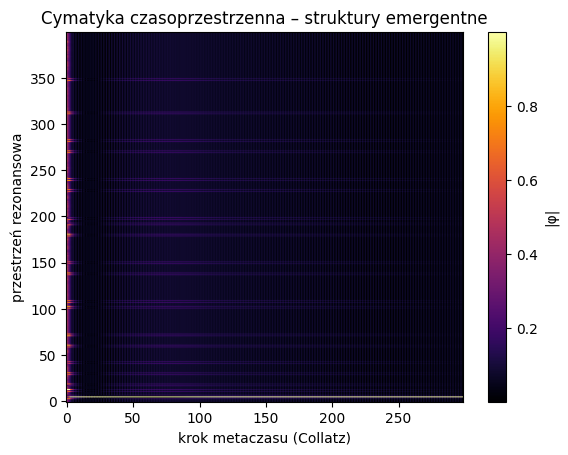

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Parametry symulacji
# -----------------------------
N_space = 400          # rozmiar przestrzeni
N_time = 300           # liczba kroków ewolucji
dx = 1.0

epsilon = 0.15         # dyfuzja (membrana)
alpha = 0.25           # napęd Collatza
beta = 1.2             # wzmocnienie rezonansowe

# -----------------------------
# 2. Operator Collatza
# -----------------------------
def collatz(n):
    return n // 2 if n % 2 == 0 else 3 * n + 1

def collatz_phase(n):
    # faza = logarytmiczny "takt"
    return np.log(collatz(n) + 1)

# -----------------------------
# 3. Twin Prime Lattice
# -----------------------------
def is_prime(n):
    if n < 2:
        return False
    for i in range(2, int(np.sqrt(n)) + 1):
        if n % i == 0:
            return False
    return True

def twin_prime_lattice(size):
    W = np.zeros(size)
    for p in range(3, size - 2):
        if is_prime(p) and is_prime(p + 2):
            W[p] += 1
            W[p + 2] += 1
    return W

W = twin_prime_lattice(N_space)

# -----------------------------
# 4. Warunek topologiczny (Ch = 1)
# -----------------------------
x = np.linspace(0, 2 * np.pi, N_space)
topological_twist = np.exp(1j * x)  # jeden pełny wir

# -----------------------------
# 5. Inicjalizacja pola
# -----------------------------
phi = np.random.normal(0, 0.05, N_space).astype(np.complex128)
phi *= topological_twist

history = []

# -----------------------------
# 6. Ewolucja
# -----------------------------
for n in range(1, N_time):
    laplacian = (
        np.roll(phi, 1) - 2 * phi + np.roll(phi, -1)
    ) / dx**2

    theta = collatz_phase(n)

    phi = (
        phi
        + epsilon * laplacian
        + alpha * np.sin(theta)
        + beta * W * phi
    )

    # stabilizacja numeryczna
    phi /= np.max(np.abs(phi)) + 1e-9

    history.append(np.abs(phi))

# -----------------------------
# 7. Wizualizacja cymatyki
# -----------------------------
plt.imshow(
    np.array(history).T,
    aspect='auto',
    origin='lower',
    cmap='inferno'
)
plt.xlabel("krok metaczasu (Collatz)")
plt.ylabel("przestrzeń rezonansowa")
plt.title("Cymatyka czasoprzestrzenna – struktury emergentne")
plt.colorbar(label="|φ|")
plt.show()